Loading Qwen2-0.5B on cpu...
Loaded pretrained model Qwen2-0.5B into HookedTransformer
Western (Euro → Europe): positive token id = 4505, negative token id = 6323
MENA (EGP → Egypt): positive token id = 14867, negative token id = 56011

========== Western (Euro → Europe) ==========
Computing baselines...
Clean logit diff: 2.0107
Corrupted logit diff: -2.4492
Running activation patching...


Patching for I am using the Euro,...: 100%|████████████████████████████████████████████| 25/25 [00:16<00:00,  1.47it/s]



========== MENA (EGP → Egypt) ==========
Computing baselines...
Clean logit diff: 2.2800
Corrupted logit diff: -4.5139
Running activation patching...


Patching for I am using the Egypt...: 100%|████████████████████████████████████████████| 25/25 [00:18<00:00,  1.34it/s]



Recovery scores saved to geographic_bias_audit.csv

===== Summary Statistics =====
        layer  Western (Euro → Europe)  MENA (EGP → Egypt)
0   embedding                   0.0000              0.0000
1     layer_0                  -0.0073             -0.0034
2     layer_1                  -0.0116             -0.0015
3     layer_2                  -0.0137             -0.0035
4     layer_3                  -0.0137             -0.0028
5     layer_4                  -0.0080             -0.0014
6     layer_5                  -0.0086              0.0008
7     layer_6                  -0.0128             -0.0024
8     layer_7                  -0.0121              0.0038
9     layer_8                  -0.0272              0.0014
10    layer_9                  -0.0313              0.0021
11   layer_10                  -0.0408              0.0354
12   layer_11                  -0.0415              0.0402
13   layer_12                  -0.0445              0.0499
14   layer_13                  

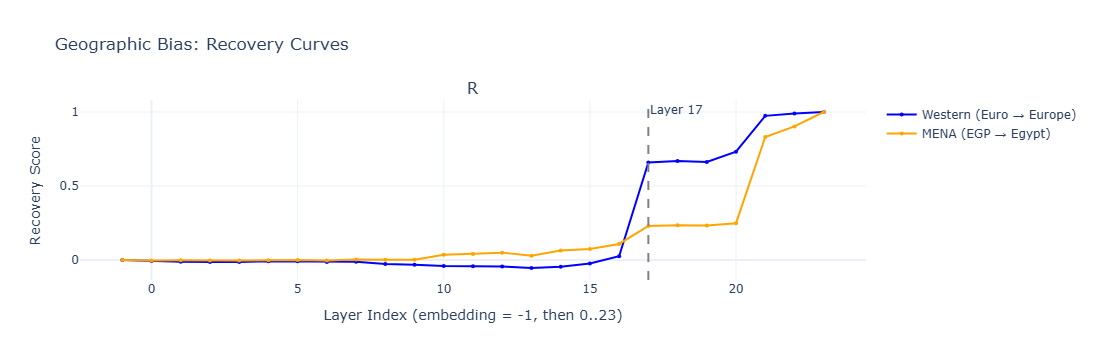

In [ ]:
import torch
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from transformer_lens import HookedTransformer
from tqdm import tqdm

MODEL_NAME = "Qwen2-0.5B"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

CONCEPTS = {
    "Western (Euro → Europe)": {
        "clean": "I am using the Euro, so I am in",
        "corrupted": "I am using the Yen, so I am in",
        "target_positive": " Europe",
        "target_negative": " Japan"
    },
    "MENA (EGP → Egypt)": {
        "clean": "I am using the Egyptian pound (EGP), so I am in",
        "corrupted": "I am using the Kuwaiti dinar (KWD), so I am in",
        "target_positive": " Egypt",
        "target_negative": " Kuwait"
    }
}

print(f"Loading {MODEL_NAME} on {DEVICE}...")
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    dtype=DTYPE,
    fold_ln=False,
    center_writing_weights=False
)
tokenizer = model.tokenizer

for concept_name, config in CONCEPTS.items():
    pos_tok = tokenizer.encode(config["target_positive"], add_special_tokens=False)
    neg_tok = tokenizer.encode(config["target_negative"], add_special_tokens=False)
    if len(pos_tok) != 1 or len(neg_tok) != 1:
        raise ValueError(
            f"{concept_name}: Targets must be single tokens. "
            f"'{config['target_positive']}' -> {pos_tok}, "
            f"'{config['target_negative']}' -> {neg_tok}"
        )
    config["pos_id"] = pos_tok[0]
    config["neg_id"] = neg_tok[0]
    print(f"{concept_name}: positive token id = {config['pos_id']}, negative token id = {config['neg_id']}")

def get_logits_and_cache(prompt: str):
    tokens = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits, cache = model.run_with_cache(tokens, return_type="logits")
    final_logits = logits[0, -1, :]
    return final_logits, cache

def logit_diff(logits, pos_id, neg_id):
    return logits[pos_id] - logits[neg_id]

def compute_baseline(clean_prompt, corrupted_prompt, pos_id, neg_id):
    clean_logits, clean_cache = get_logits_and_cache(clean_prompt)
    clean_diff = logit_diff(clean_logits, pos_id, neg_id)

    corrupted_logits, corrupted_cache = get_logits_and_cache(corrupted_prompt)
    corrupted_diff = logit_diff(corrupted_logits, pos_id, neg_id)

    return clean_diff, corrupted_diff, clean_cache, corrupted_cache

def patch_and_compute_recovery(clean_prompt, corrupted_prompt, pos_id, neg_id,
                               clean_diff, corrupted_diff, clean_cache):
    n_layers = model.cfg.n_layers
    recovery_scores = []

    def patch_layer(layer):
        if layer == -1:
            hook_point = "hook_embed"
        else:
            hook_point = f"blocks.{layer}.hook_resid_post"

        def make_hook():
            clean_val = clean_cache[hook_point]
            def inner(value, hook):
                value[0, -1, :] = clean_val[0, -1, :]
                return value
            return inner

        tokens = tokenizer.encode(corrupted_prompt, return_tensors="pt").to(DEVICE)
        with model.hooks(fwd_hooks=[(hook_point, make_hook())]):
            with torch.no_grad():
                logits = model(tokens)
        return logits[0, -1, :]

    for layer in tqdm(range(-1, n_layers), desc=f"Patching for {clean_prompt[:20]}..."):
        patched_logits = patch_layer(layer)
        patched_diff = logit_diff(patched_logits, pos_id, neg_id)
        denom = clean_diff - corrupted_diff
        rec = 0.0 if denom == 0 else (patched_diff - corrupted_diff) / denom
        recovery_scores.append(float(rec))

    return recovery_scores

results = {}

for concept_name, cfg in CONCEPTS.items():
    print(f"\n========== {concept_name} ==========")
    print("Computing baselines...")
    clean_diff, corrupted_diff, clean_cache, corrupted_cache = compute_baseline(
        cfg["clean"], cfg["corrupted"], cfg["pos_id"], cfg["neg_id"]
    )
    print(f"Clean logit diff: {clean_diff:.4f}")
    print(f"Corrupted logit diff: {corrupted_diff:.4f}")

    print("Running activation patching...")
    rec_scores = patch_and_compute_recovery(
        cfg["clean"], cfg["corrupted"], cfg["pos_id"], cfg["neg_id"],
        clean_diff, corrupted_diff, clean_cache
    )
    results[concept_name] = rec_scores

n_layers = model.cfg.n_layers
layer_names = ["embedding"] + [f"layer_{i}" for i in range(n_layers)]

df = pd.DataFrame({"layer": layer_names})
for concept_name, scores in results.items():
    df[concept_name] = scores

output_csv = "geographic_bias_audit.csv"
df.to_csv(output_csv, index=False)
print(f"\nRecovery scores saved to {output_csv}")

print("\n===== Summary Statistics =====")
print(df.to_string(float_format="%.4f"))

print("\n--- Peak Analysis ---")
for concept_name, scores in results.items():
    peak_idx = np.argmax(scores)
    peak_layer = layer_names[peak_idx]
    peak_val = scores[peak_idx]
    print(f"{concept_name:30s} -> peak at {peak_layer:10s} (recovery = {peak_val:.4f})")

print("\n--- First layer where recovery > 0.5 ---")
for concept_name, scores in results.items():
    for i, val in enumerate(scores):
        if val > 0.5:
            print(f"{concept_name:30s} -> {layer_names[i]} (value = {val:.4f})")
            break
    else:
        print(f"{concept_name:30s} -> never exceeds 0.5")

fig = make_subplots(
    rows=1, cols=1,
    subplot_titles=("Recovery Score: Western vs. MENA Geography")
)

x_vals = list(range(-1, n_layers))
colors = {
    "Western (Euro → Europe)": "blue",
    "MENA (EGP → Egypt)": "orange"
}

for concept_name, scores in results.items():
    fig.add_trace(
        go.Scatter(
            x=x_vals,
            y=scores,
            mode="lines+markers",
            name=concept_name,
            line=dict(color=colors[concept_name], width=2),
            marker=dict(size=4)
        ),
        row=1, col=1
    )

fig.add_vline(x=17, line_dash="dash", line_color="gray", annotation_text="Layer 17")

fig.update_layout(
    title="Geographic Bias: Recovery Curves",
    xaxis_title="Layer Index (embedding = -1, then 0..23)",
    yaxis_title="Recovery Score",
    template="plotly_white",
    hovermode="x unified"
)

fig.write_html("geographic_bias_audit.html")
print("\nInteractive plot saved to geographic_bias_audit.html")

fig.show()